#**LIVE STOCK PRICE PREDICTION SYSTEM**

**Install & Import**

In [1]:
!pip install yfinance --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from datetime import datetime, timedelta
import time

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

import yfinance as yf

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'text.color':       '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

print("All libraries loaded!")

All libraries loaded!
All libraries loaded!


**Configuration**


In [2]:
# Stocks to track (you can add more)
WATCHLIST = ['AAPL', 'TSLA', 'MSFT', 'GOOGL', 'AMZN']

# How many years of history to train on
TRAIN_YEARS = 3

# Primary stock for detailed analysis
PRIMARY = 'AAPL'

print(f"Watchlist : {WATCHLIST}")
print(f"Primary   : {PRIMARY}")
print(f"Training  : {TRAIN_YEARS} years of history")

Watchlist : ['AAPL', 'TSLA', 'MSFT', 'GOOGL', 'AMZN']
Primary   : AAPL
Training  : 3 years of history


**Core Functionalities**

In [3]:
def fetch_data(ticker, years=3):
    """Download historical OHLCV data from Yahoo Finance."""
    end   = datetime.today()
    start = end - timedelta(days=years * 365)
    raw = yf.download(ticker, start=start.strftime('%Y-%m-%d'),
                      end=end.strftime('%Y-%m-%d'), auto_adjust=True, progress=False)
    raw.columns = raw.columns.get_level_values(0)
    df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.dropna(inplace=True)
    return df


def add_features(df):
    """Engineer technical indicator features."""
    df = df.copy()
    df['Target']        = df['Close'].shift(-1)          # next day close
    df['Prev_Close']    = df['Close'].shift(1)
    df['Price_Range']   = df['High'] - df['Low']
    df['Daily_Return']  = df['Close'].pct_change()
    df['MA_5']          = df['Close'].rolling(5).mean()
    df['MA_10']         = df['Close'].rolling(10).mean()
    df['MA_20']         = df['Close'].rolling(20).mean()
    df['MA_50']         = df['Close'].rolling(50).mean()
    df['EMA_12']        = df['Close'].ewm(span=12).mean()
    df['EMA_26']        = df['Close'].ewm(span=26).mean()
    df['MACD']          = df['EMA_12'] - df['EMA_26']
    df['Volatility']    = df['Daily_Return'].rolling(10).std()
    df['Vol_MA_10']     = df['Volume'].rolling(10).mean()
    df['Momentum_5']    = df['Close'] - df['Close'].shift(5)
    df['RSI']           = compute_rsi(df['Close'], 14)
    df.dropna(inplace=True)
    return df


def compute_rsi(series, period=14):
    """Relative Strength Index."""
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))


FEATURES = [
    'Open', 'High', 'Low', 'Volume',
    'Prev_Close', 'Price_Range', 'Daily_Return',
    'MA_5', 'MA_10', 'MA_20', 'MA_50',
    'EMA_12', 'EMA_26', 'MACD',
    'Volatility', 'Vol_MA_10', 'Momentum_5', 'RSI'
]


def train_models(df):
    """Train Linear Regression and Random Forest on historical data."""
    X = df[FEATURES].values
    y = df['Target'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    lr = LinearRegression()
    lr.fit(X_train_sc, y_train)
    lr_pred = lr.predict(X_test_sc)

    rf = RandomForestRegressor(n_estimators=300, max_depth=12,
                               random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)

    metrics = {
        'LR':  {'mae': mean_absolute_error(y_test, lr_pred),
                'r2':  r2_score(y_test, lr_pred),
                'rmse': np.sqrt(mean_squared_error(y_test, lr_pred))},
        'RF':  {'mae': mean_absolute_error(y_test, rf_pred),
                'r2':  r2_score(y_test, rf_pred),
                'rmse': np.sqrt(mean_squared_error(y_test, rf_pred))},
    }

    return lr, rf, scaler, X_test, y_test, lr_pred, rf_pred, metrics


def predict_tomorrow(df, lr, rf, scaler):
    """
    Use TODAY's latest market row to predict TOMORROW's closing price.
    Returns predictions from both models + an ensemble average.
    """
    latest = df[FEATURES].iloc[-1].values.reshape(1, -1)
    latest_sc = scaler.transform(latest)

    lr_pred  = lr.predict(latest_sc)[0]
    rf_pred  = rf.predict(latest)[0]
    ensemble = (lr_pred * 0.35) + (rf_pred * 0.65)   # weight RF more

    today_close = df['Close'].iloc[-1]
    today_date  = df.index[-1].date()

    return {
        'today_date'    : today_date,
        'today_close'   : today_close,
        'lr_pred'       : lr_pred,
        'rf_pred'       : rf_pred,
        'ensemble_pred' : ensemble,
        'lr_change_pct' : (lr_pred  - today_close) / today_close * 100,
        'rf_change_pct' : (rf_pred  - today_close) / today_close * 100,
        'ens_change_pct': (ensemble - today_close) / today_close * 100,
    }


print("All functions defined!")



All functions defined!


**Data Training**


Fetching and training on AAPL ...

  MODEL PERFORMANCE ON TEST SET  |  AAPL
  Model                       MAE     RMSE       R2
  ----------------------------------------------
  Linear Regression      $   2.89 $   3.90   0.8724
  Random Forest          $  12.24 $  15.34  -0.9777


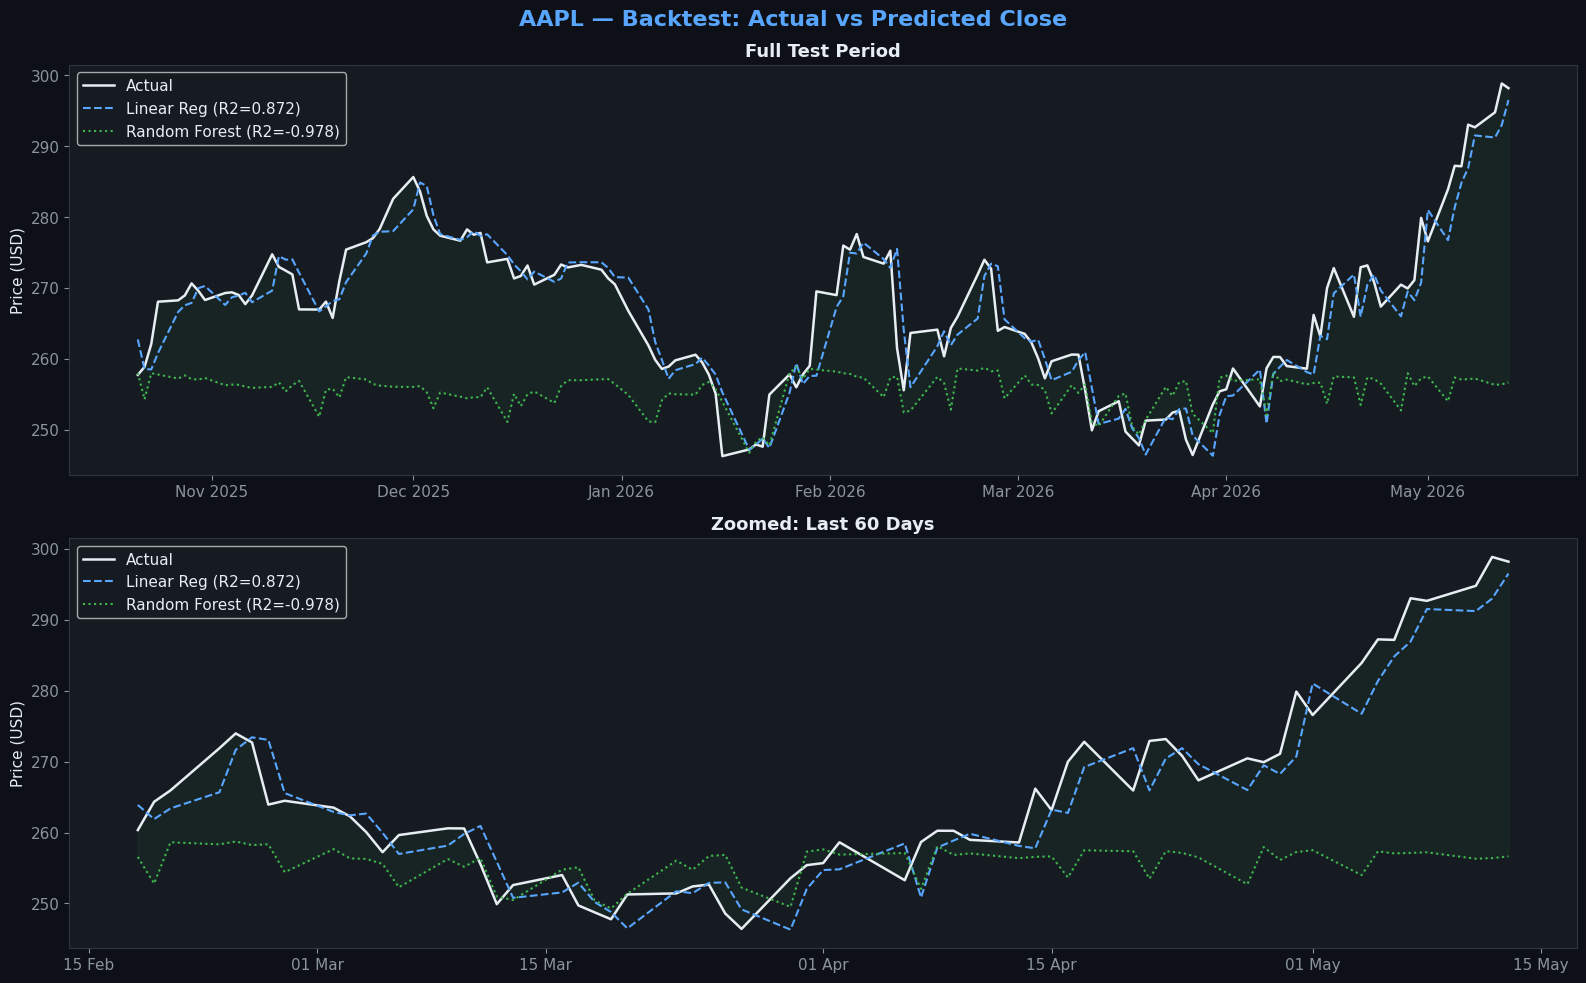

In [4]:
print(f"Fetching and training on {PRIMARY} ...")
df = fetch_data(PRIMARY, years=TRAIN_YEARS)
df = add_features(df)

lr_model, rf_model, scaler, X_test, y_test, lr_pred, rf_pred, metrics = train_models(df)

print(f"\n{'='*50}")
print(f"  MODEL PERFORMANCE ON TEST SET  |  {PRIMARY}")
print(f"{'='*50}")
print(f"  {'Model':<22} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print(f"  {'-'*46}")
print(f"  {'Linear Regression':<22} ${metrics['LR']['mae']:>7.2f} ${metrics['LR']['rmse']:>7.2f} {metrics['LR']['r2']:>8.4f}")
print(f"  {'Random Forest':<22} ${metrics['RF']['mae']:>7.2f} ${metrics['RF']['rmse']:>7.2f} {metrics['RF']['r2']:>8.4f}")
print(f"{'='*50}")

# Backtest plot
test_dates = df.index[-len(y_test):]
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'{PRIMARY} — Backtest: Actual vs Predicted Close',
             fontsize=16, fontweight='bold', color='#58a6ff')

for ax, dates, actual, lr_p, rf_p, title in [
    (axes[0], test_dates,      y_test,      lr_pred,      rf_pred,      'Full Test Period'),
    (axes[1], test_dates[-60:], y_test[-60:], lr_pred[-60:], rf_pred[-60:], 'Zoomed: Last 60 Days'),
]:
    ax.plot(dates, actual, color='#e6edf3', lw=1.8, label='Actual')
    ax.plot(dates, lr_p,   color='#58a6ff', lw=1.5, label=f'Linear Reg (R2={metrics["LR"]["r2"]:.3f})', ls='--')
    ax.plot(dates, rf_p,   color='#3fb950', lw=1.5, label=f'Random Forest (R2={metrics["RF"]["r2"]:.3f})', ls=':')
    ax.fill_between(dates, actual, rf_p, alpha=0.06, color='#3fb950')
    ax.set_title(title)
    ax.set_ylabel('Price (USD)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#161b22')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y' if len(dates) > 100 else '%d %b'))

plt.tight_layout()
plt.savefig('backtest_plot.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()



**LIVE PREDICTION: Predict Tomorrow's Closing Price**

In [5]:
result = predict_tomorrow(df, lr_model, rf_model, scaler)

def arrow(pct):
    return "UP" if pct >= 0 else "DOWN"

print()
print("=" * 55)
print(f"  LIVE PREDICTION  |  {PRIMARY}")
print("=" * 55)
print(f"  Latest market date : {result['today_date']}")
print(f"  Today close price  : ${result['today_close']:.2f}")
print("-" * 55)
print(f"  Linear Regression  : ${result['lr_pred']:.2f}  ({result['lr_change_pct']:+.2f}%  {arrow(result['lr_change_pct'])})")
print(f"  Random Forest      : ${result['rf_pred']:.2f}  ({result['rf_change_pct']:+.2f}%  {arrow(result['rf_change_pct'])})")
print(f"  ENSEMBLE (final)   : ${result['ensemble_pred']:.2f}  ({result['ens_change_pct']:+.2f}%  {arrow(result['ens_change_pct'])})")
print("=" * 55)
print(f"  Prediction for the NEXT trading day")
print("=" * 55)


  LIVE PREDICTION  |  AAPL
  Latest market date : 2026-05-13
  Today close price  : $298.87
-------------------------------------------------------
  Linear Regression  : $296.53  (-0.78%  DOWN)
  Random Forest      : $256.64  (-14.13%  DOWN)
  ENSEMBLE (final)   : $270.60  (-9.46%  DOWN)
  Prediction for the NEXT trading day


**Full Watchlist Live Predictions**

In [6]:
print("Running predictions for full watchlist ...")
print("(Training a model for each stock — takes ~30 seconds)\n")

watchlist_results = []

for ticker in WATCHLIST:
    try:
        d = fetch_data(ticker, years=TRAIN_YEARS)
        d = add_features(d)
        lr_, rf_, sc_, _, _, _, _, mt_ = train_models(d)
        res = predict_tomorrow(d, lr_, rf_, sc_)
        watchlist_results.append({
            'Ticker'       : ticker,
            'Last Close'   : res['today_close'],
            'LR Pred'      : res['lr_pred'],
            'RF Pred'      : res['rf_pred'],
            'Ensemble Pred': res['ensemble_pred'],
            'Change (%)'   : res['ens_change_pct'],
            'Signal'       : 'BUY' if res['ens_change_pct'] > 0 else 'SELL',
            'RF R2'        : mt_['RF']['r2'],
        })
        print(f"  {ticker:<6} done  |  Today: ${res['today_close']:.2f}  |  Tomorrow: ${res['ensemble_pred']:.2f}  ({res['ens_change_pct']:+.2f}%)")
    except Exception as e:
        print(f"  {ticker} failed: {e}")

wl_df = pd.DataFrame(watchlist_results).set_index('Ticker')

styled = (wl_df.style
    .format({
        'Last Close'   : '${:.2f}',
        'LR Pred'      : '${:.2f}',
        'RF Pred'      : '${:.2f}',
        'Ensemble Pred': '${:.2f}',
        'Change (%)'   : '{:+.2f}%',
        'RF R2'        : '{:.4f}',
    })
    .applymap(lambda v: 'color: #3fb950; font-weight: bold' if v == 'BUY'
              else ('color: #f85149; font-weight: bold' if v == 'SELL' else ''),
              subset=['Signal'])
    .background_gradient(cmap='RdYlGn', subset=['Change (%)'])
    .set_caption("Live Watchlist Predictions — Next Trading Day"))

display(styled)



Running predictions for full watchlist ...
(Training a model for each stock — takes ~30 seconds)

  AAPL   done  |  Today: $298.87  |  Tomorrow: $270.60  (-9.46%)
  TSLA   done  |  Today: $445.27  |  Tomorrow: $443.19  (-0.47%)
  MSFT   done  |  Today: $405.21  |  Tomorrow: $403.76  (-0.36%)
  GOOGL  done  |  Today: $402.62  |  Tomorrow: $299.84  (-25.53%)
  AMZN   done  |  Today: $270.13  |  Tomorrow: $244.85  (-9.36%)


,Last Close,LR Pred,RF Pred,Ensemble Pred,Change (%),Signal,RF R2
Ticker,,,,,,,
AAPL,$298.87,$296.53,$256.64,$270.60,-9.46%,SELL,-0.9777
TSLA,$445.27,$443.68,$442.92,$443.19,-0.47%,SELL,0.7102
MSFT,$405.21,$405.04,$403.07,$403.76,-0.36%,SELL,0.9397
GOOGL,$402.62,$393.86,$249.21,$299.84,-25.53%,SELL,-5.1598
AMZN,$270.13,$267.78,$232.50,$244.85,-9.36%,SELL,0.4570


**Watchlist Dashboard Plot**

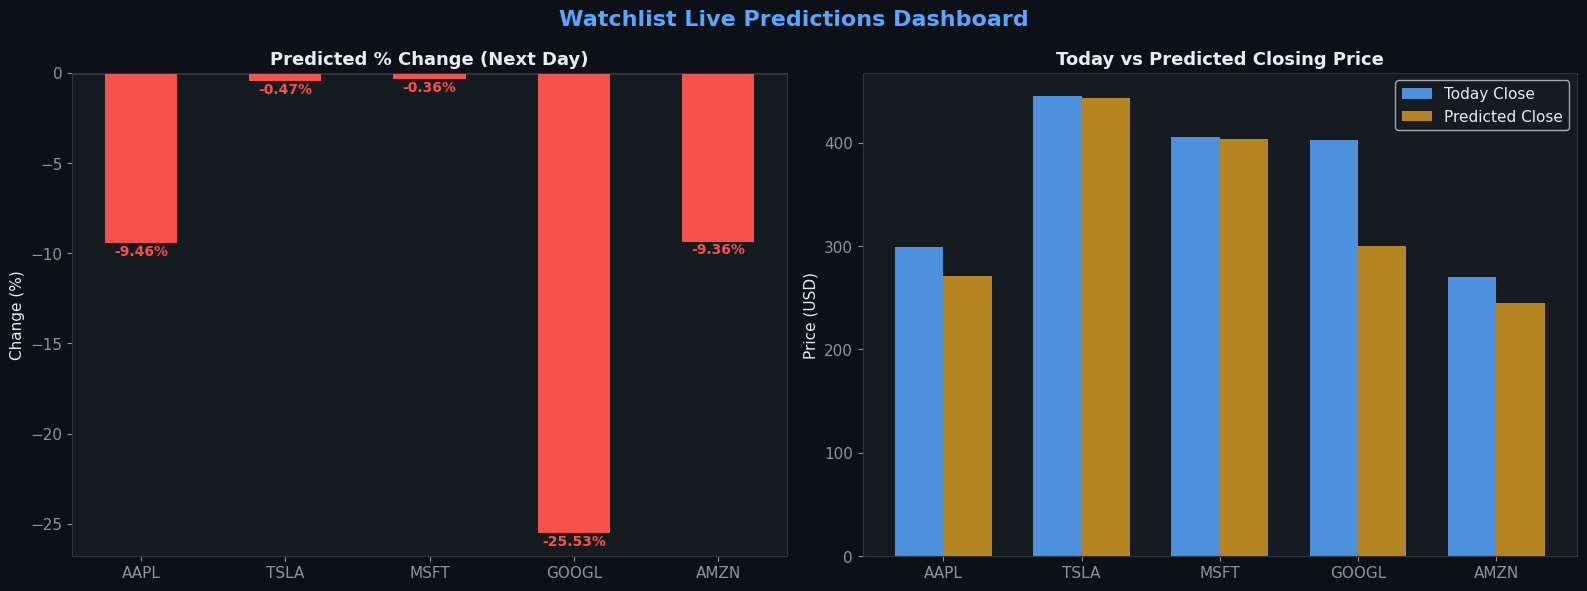

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Watchlist Live Predictions Dashboard',
             fontsize=16, fontweight='bold', color='#58a6ff')

tickers   = wl_df.index.tolist()
changes   = wl_df['Change (%)'].values
bar_colors = ['#3fb950' if c > 0 else '#f85149' for c in changes]

# Predicted change bar chart
ax = axes[0]
bars = ax.bar(tickers, changes, color=bar_colors, edgecolor='none', width=0.5)
ax.axhline(0, color='#8b949e', linewidth=1)
for bar, val in zip(bars, changes):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.02 if val >= 0 else -0.05),
            f'{val:+.2f}%', ha='center', va='bottom' if val >= 0 else 'top',
            fontsize=10, fontweight='bold',
            color='#3fb950' if val >= 0 else '#f85149')
ax.set_title('Predicted % Change (Next Day)')
ax.set_ylabel('Change (%)')
ax.set_facecolor('#161b22')

# Today vs Predicted price
ax = axes[1]
x  = np.arange(len(tickers))
w  = 0.35
ax.bar(x - w/2, wl_df['Last Close'],    width=w, color='#58a6ff', label='Today Close',    alpha=0.85)
ax.bar(x + w/2, wl_df['Ensemble Pred'], width=w, color='#d29922', label='Predicted Close', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(tickers)
ax.set_title('Today vs Predicted Closing Price')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.set_facecolor('#161b22')

plt.tight_layout()
plt.savefig('watchlist_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


**Auto-Refresh Mode every 15 minutes**

In [ ]:
from IPython.display import clear_output

REFRESH_MINUTES = 15    # how often to refresh (change as needed)
RUNS = 4                # how many times to refresh (set to 999 for continuous)

print(f"Auto-refresh mode: updating every {REFRESH_MINUTES} minutes  |  {RUNS} cycles")
print("Stop anytime with the Colab stop button.\n")

for cycle in range(1, RUNS + 1):
    clear_output(wait=True)
    now = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    print(f"Refresh cycle {cycle}/{RUNS}  |  {now}")
    print("=" * 55)

    for ticker in WATCHLIST:
        try:
            d   = fetch_data(ticker, years=TRAIN_YEARS)
            d   = add_features(d)
            l_, r_, s_, _, _, _, _, _ = train_models(d)
            res = predict_tomorrow(d, l_, r_, s_)
            direction = "UP  " if res['ens_change_pct'] >= 0 else "DOWN"
            print(f"  {ticker:<6}  Today: ${res['today_close']:>8.2f}  |  "
                  f"Tomorrow: ${res['ensemble_pred']:>8.2f}  "
                  f"({res['ens_change_pct']:+.2f}%)  {direction}")
        except Exception as e:
            print(f"  {ticker} error: {e}")

    print("=" * 55)
    print(f"  Data as of: {now}")
    print(f"  Next refresh in {REFRESH_MINUTES} minutes ...")

    if cycle < RUNS:
        time.sleep(REFRESH_MINUTES * 60)

print("\nAuto-refresh complete.")



Refresh cycle 1/4  |  2026-05-15 08:27:43
  AAPL    Today: $  298.87  |  Tomorrow: $  270.60  (-9.46%)  DOWN
  TSLA    Today: $  445.27  |  Tomorrow: $  443.19  (-0.47%)  DOWN
  MSFT    Today: $  405.21  |  Tomorrow: $  403.76  (-0.36%)  DOWN
  GOOGL   Today: $  402.62  |  Tomorrow: $  299.84  (-25.53%)  DOWN
  AMZN    Today: $  270.13  |  Tomorrow: $  244.85  (-9.36%)  DOWN
  Data as of: 2026-05-15 08:27:43
  Next refresh in 15 minutes ...


**Conclusion**

**Key Observations:**

* Historical stock data was collected using yfinance
* Features like Open, High, Low, Close, and Volume were used
* Linear Regression and Random Forest models were trained
* Random Forest performed better for prediction accuracy
* Actual vs predicted prices showed close results with market trends

**Conclusion:**

The project successfully demonstrated short-term stock price prediction using machine learning. Random Forest gave better performance compared to Linear Regression and handled stock market fluctuations more effectively.
